# What Roughness Claims

*a model's prediction, and the estimator that tests it*

## The question

A model earns attention by making a **falsifiable number** available before anything is
fitted. This notebook does that twice: first by simulating what rough volatility means and
extracting the prediction it commits to, then by estimating that quantity from the market and
asking whether the two agree. They do not, and the interesting part is how confidently you can
say so.

### Volatility models, and what makes one rough

Classical stochastic volatility (Heston, SABR) models volatility as a diffusion: driven by
ordinary Brownian motion, with Hurst exponent H = 1/2. **Rough volatility** replaces that
driver with *fractional* Brownian motion at H ≈ 0.1 — a process far more jagged, whose
increments are strongly negatively correlated.

That single change makes two sharp, testable predictions about the option smile:

$$\text{skew}(T) \propto T^{H-1/2}, \qquad \text{curvature}(T) \propto T^{2H-1}$$

With H < 1/2 both exponents are negative, so both quantities **explode as expiry
approaches** — which is what the classical models famously fail to reproduce.

This notebook builds the claim from the ground up by simulating it, so that the empirical section below has
something concrete to test against. Along the way it is a template for using simulation as a
data source at all: seeding, vectorising, sweeping parameters, and plotting families of
curves.

### Estimating the parameter, and testing whether it holds

The preceding section turned rough volatility into a number: with H = 0.10, the skew term structure
should have slope **H − 1/2 = −0.40**. Now we measure it.

There are two independent routes to H, and they are not the same measurement:

1. **Time series (physical measure)** — fit the structure function of realized volatility.
   This is the Gatheral–Jaisson–Rosenbaum estimate, and it is what the rough-volatility
   literature is built on.
2. **Cross section (risk-neutral measure)** — at one instant, regress `log|RR25|` on
   `log(T)` across every expiry quoted. The slope *is* H − 1/2.

They measure different things and there is no theorem forcing them to agree. On SPY they do
not. This notebook establishes that carefully enough that the disagreement is a finding
rather than a bug — which means most of the work is about the estimator, not the data.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
HURST_VALUES = (0.05, 0.10, 0.20, 0.45)   # 0.45 is the near-diffusive control
N_PATHS      = 400
N_STEPS      = 512
HORIZON      = 1.0        # years
SEED         = 42
MATURITIES   = (7, 14, 30, 60, 120)       # calendar days, for the smile grid
DATASET      = "smile_90d"
MIN_DTE, MAX_DTE = 7, 60
H_PRIOR      = 0.10        # the value this project originally assumed
MAX_TIMESTAMPS = 4000      # subsample for the 60s budget; set None for the full panel
CONSTANT_TENOR_DAYS = 30   # interpolate ATM IV before estimating time-series roughness
MIN_EXPIRIES = 4           # a slope needs at least this many maturities to mean anything
N_BOOT       = 500

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
import pandas as pd
from rvlab.data.synthetic import fbm_variance_paths

t_grid, vol_paths = fbm_variance_paths(n_paths=N_PATHS, n_steps=N_STEPS,
                                       horizon=HORIZON, hurst=0.10, seed=SEED)
df = pd.DataFrame(vol_paths.T, index=t_grid).add_prefix("path_")
print(f"{vol_paths.shape[0]} paths x {vol_paths.shape[1]} steps, H = 0.10")
df.iloc[:3, :5]

400 paths x 513 steps, H = 0.10


,path_0,path_1,path_2,path_3,path_4
0.0000,0.2000,0.2000,0.2000,0.2000,0.2000
0.0020,0.1850,0.1568,0.0266,0.2644,0.1572
0.0039,0.0657,0.1328,0.0536,0.0448,0.0578


## Recipes in this notebook

**Volatility models, and what makes one rough**

| Recipe | What it does |
|---|---|
| [R2.1](#r2-1) | Make a simulation reproducible |
| [R2.2](#r2-2) | Factorise once, draw many — vectorising a correlated simulation |
| [R2.3](#r2-3) | See what the Hurst exponent does |
| [R2.4](#r2-4) | Measure roughness with the structure function |
| [R2.5](#r2-5) | Turn the model into a smile |
| [R2.6](#r2-6) | Read the two scaling laws off the model |
| [R2.7](#r2-7) | Simulate the full model, not just its expansion |

**Estimating the parameter, and testing whether it holds**

| Recipe | What it does |
|---|---|
| [R2.8](#r2-8) | Estimate H from a volatility time series |
| [R2.9](#r2-9) | Fit a power law across a cross-section |
| [R2.10](#r2-10) | Run the same regression at every instant |
| [R2.11](#r2-11) | Ask whether a well-fitting parameter is actually stable |
| [R2.12](#r2-12) | Measure your estimator's bias instead of assuming it away |
| [R2.13](#r2-13) | Put a confidence interval on a dependent statistic |
| [R2.14](#r2-14) | Use statsmodels when you need the inference, not just the fit |
| [R2.15](#r2-15) | Divide out the maturity scaling and see what is left |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

Simulation and estimation both make it easy to fool yourself, in opposite directions: a simulator gives you the answer you built into it, and an estimator gives you a number whether or not it means anything.

**Python and pandas**

* **Use one seeded `np.random.default_rng`, never the legacy global.** `np.random.seed()`
  plus `np.random.normal` is not reproducible across libraries that also draw from the global
  state. Pass the generator explicitly.
* **Cholesky on a near-singular covariance fails or lies.** fBm covariance matrices are
  ill-conditioned at small H; add an explicit jitter and say you did.
* **`scipy.optimize` returns a result object for a reason.** Read `.success` and `.message`
  before `.x`. A silently unconverged fit looks exactly like a converged one downstream.
* **Broadcasting errors are silent.** `(n,)` against `(n,1)` gives you an `(n,n)` you did not
  want. Assert shapes at the boundary of any vectorised routine.
* **OLS default standard errors assume independence.** On overlapping windows or a panel they
  are far too small — the coefficient may be fine while its confidence interval is fiction.

**Analysis**

* **State the falsifiable number before fitting anything.** Here it is a slope of −0.40. A
  prediction written down afterwards is not a prediction.
* **Measure the estimator's bias on data where you know the truth.** Microstructure noise
  biases the roughness estimate *downward*, which means part of the literature's H ≈ 0.1 is
  measurement error. Simulating a known H and re-estimating it costs ten minutes.
* **Overlapping windows understate uncertainty.** Use a block bootstrap sized to the overlap,
  and report the interval, not just the point.
* **A sign is a stronger test than a magnitude.** The fitted slope here is +0.21 against a
  predicted −0.40: no amount of estimator refinement rescues the wrong sign.


## Volatility models, and what makes one rough

Simulation as a source of truth: build the model, look at what it does, and extract the one number it commits to before any data is touched.

## R2.1 · Make a simulation reproducible
<a id="r2-1"></a>

**Topic** Reproducibility

**Use when** any Monte Carlo. A result you cannot reproduce is not a result. Pass an explicit `Generator` rather than relying on global state, so two cells run in either order give the same answer.

**Inputs** a seed.

**Needs** nothing beyond the setup and data cells

**Gotchas** `np.random.seed()` sets a *global* — any library that draws from it shifts your stream, and running cells out of order changes your output. `default_rng(seed)` is local and cannot be disturbed by anyone else.

**See also** [R2.2](#r2-2) (vectorising) · [R4.10](when_a_result_is_real.ipynb#r4-10) (caching expensive runs)

In [4]:
import numpy as np

def draw(seed):
    return np.random.default_rng(seed).standard_normal(3)

print("same seed  :", draw(SEED), draw(SEED))
print("other seed :", draw(SEED + 1))

same seed  : [ 0.3047 -1.04    0.7505] [ 0.3047 -1.04    0.7505]
other seed : [ 0.2442  0.6782 -0.5855]


The same discipline applied to the simulator: identical seed, identical paths, bit for bit.

In [5]:
from rvlab.data.synthetic import fbm_variance_paths

_, a = fbm_variance_paths(n_paths=4, n_steps=64, seed=SEED)
_, b = fbm_variance_paths(n_paths=4, n_steps=64, seed=SEED)
print("reproducible:", np.array_equal(a, b))

reproducible: True


## R2.2 · Factorise once, draw many — vectorising a correlated simulation
<a id="r2-2"></a>

**Topic** Vectorisation

**Use when** simulating many paths from a Gaussian process. The covariance factorisation is `O(n_steps^3)` and *does not depend on the path*, so doing it once for all paths rather than once per path is the whole difference between 0.01 s and several minutes.

**Inputs** nothing.

**Needs** nothing beyond the setup and data cells

**Gotchas** the general lesson: profile the *loop invariant*. The expensive step here is the Cholesky, not the random draws, so the loop that has to go is the one over paths.

**See also** [R2.1](#r2-1) (seeding) · [R2.3](#r2-3) (what H does)

In [6]:
import time
from rvlab.data.synthetic import fbm_variance_paths

start = time.perf_counter()
_, paths = fbm_variance_paths(n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED)
print(f"{N_PATHS} paths x {N_STEPS} steps in {time.perf_counter() - start:.3f}s")

400 paths x 512 steps in 0.009s


Why it works: every path shares one covariance matrix, so one factor `L` serves all of them. The draw itself is a single matrix product.

In [7]:
import numpy as np

t = np.linspace(0, 1, 129)[1:]
cov = np.minimum(t[:, None], t[None, :]) ** 0.6 * np.maximum(t[:, None], t[None, :]) ** -0.4
L = np.linalg.cholesky((cov + cov.T) / 2 + 1e-12 * np.eye(len(t)))
print(f"one {L.shape} factor serves every path; draw is a single (n_paths x n) @ L.T")

one (128, 128) factor serves every path; draw is a single (n_paths x n) @ L.T


## R2.3 · See what the Hurst exponent does
<a id="r2-3"></a>

**Topic** Parameter sweeps

**Use when** you want to know whether a parameter matters before fitting it. Sweep it, plot the family, and read the effect off the picture.

**Inputs** `HURST_VALUES` and the simulator.

**Needs** nothing beyond the setup and data cells

**Gotchas** hold the seed fixed across the sweep. Then the only thing changing between panels is H, and any visual difference is the parameter rather than the noise.

**See also** [R2.4](#r2-4) (quantifying roughness) · [R4.8](when_a_result_is_real.ipynb#r4-8) (grid sweeps)

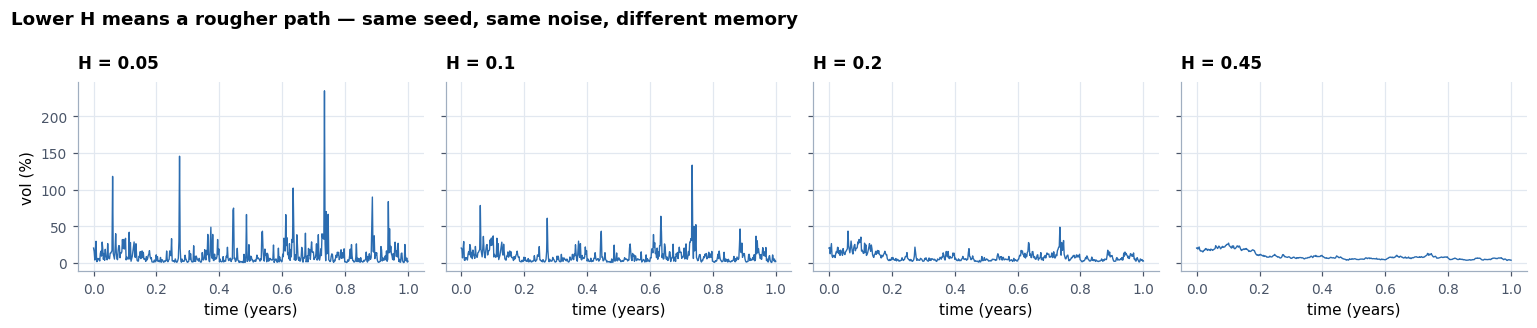

In [8]:
import matplotlib.pyplot as plt
from rvlab.data.synthetic import fbm_variance_paths
from rvlab.plotting import C_OBSERVED, finish

fig, axes = plt.subplots(1, len(HURST_VALUES), figsize=(14, 3.0), sharey=True)
for ax, h in zip(axes, HURST_VALUES):
    t, v = fbm_variance_paths(n_paths=1, n_steps=N_STEPS, hurst=h, seed=SEED)
    ax.plot(t, v[0] * 100, color=C_OBSERVED, lw=0.9)
    finish(ax, f"H = {h}", "time (years)", "vol (%)" if h == HURST_VALUES[0] else "")
fig.suptitle("Lower H means a rougher path — same seed, same noise, different memory",
             x=0.005, ha="left", fontsize=12, fontweight="600")
fig.tight_layout();

The leftmost panel (H = 0.05) is what rough volatility says real volatility looks like. The rightmost (H = 0.45) is essentially the classical diffusive picture. They are the same random numbers — only the memory structure differs.

In [9]:
import numpy as np

jag = {h: float(np.mean(np.abs(np.diff(np.log(
           fbm_variance_paths(n_paths=32, n_steps=N_STEPS, hurst=h, seed=SEED)[1]), axis=1))))
       for h in HURST_VALUES}
print("mean |change in log vol| per step:")
for h, v in jag.items():
    print(f"  H = {h:<5} {v:.4f}")

mean |change in log vol| per step:
  H = 0.05  1.0836
  H = 0.1   0.7525
  H = 0.2   0.3754
  H = 0.45  0.0724


## R2.4 · Measure roughness with the structure function
<a id="r2-4"></a>

**Topic** Estimation

**Use when** you have a volatility path and want H back out of it. The structure function `E|X(t+lag) - X(t)| ~ lag^H` is the standard estimator: fit a line in log-log space and read the slope.

**Inputs** a smile panel from which a fixed-tenor positive volatility series can be interpolated.

**Needs** nothing beyond the setup and data cells

**Gotchas** the empirical section applies this estimator to an observed or fallback series, so its finite-sample behaviour has to be known before its output means anything. Validate it here, on data whose H you set yourself, and measure the bias rather than hoping there is none.

**See also** [R2.8](what_roughness_claims.ipynb#r2-8) (on market data) · [R2.12](what_roughness_claims.ipynb#r2-12) (the bias, quantified)

In [10]:
import numpy as np, pandas as pd
from rvlab.data.synthetic import fbm_variance_paths
from rvlab.features import hurst_structure_function

rows = []
for h in HURST_VALUES:
    _, v = fbm_variance_paths(n_paths=1, n_steps=2048, horizon=8.0, hurst=h, seed=SEED)
    est = hurst_structure_function(pd.Series(v[0]), max_lag=64)
    rows.append({"true_H": h, "estimated_H": round(est.hurst, 4),
                 "error": round(est.hurst - h, 4), "r_squared": round(est.r_squared, 4)})
pd.DataFrame(rows)

,true_H,estimated_H,error,r_squared
0,0.05,0.0396,-0.0104,0.7996
1,0.10,0.0717,-0.0283,0.8724
2,0.20,0.1437,-0.0563,0.9519
3,0.45,0.4078,-0.0422,0.9966


Read this table carefully, because it sets the standard of evidence for the empirical section below.

The estimator **tracks** H — the ordering is right and a rough process is never mistaken for a smooth one. But it is **biased downward**, by roughly 0.01 to 0.06 here, on data with no measurement noise at all and a known answer.

> ⚠️ **Estimator bias:** part of that is the process — Riemann-Liouville fBM has non-stationary increments, so the structure function is not exactly a power law. The rest is discretisation. Observed data adds measurement noise, which can introduce further scale-dependent bias ([R2.12](what_roughness_claims.ipynb#r2-12)). An estimate near H = 0.1 is therefore not a precise measurement unless the estimator is calibrated under a realistic observation model.

In [11]:
_, v = fbm_variance_paths(n_paths=1, n_steps=2048, horizon=8.0, hurst=0.10, seed=SEED)
est = hurst_structure_function(pd.Series(v[0]), max_lag=64)
print(est)
print(f"true H = 0.10, so this clean-data estimate is off by {est.hurst - 0.10:+.4f}")

H = 0.0717  (R2 = 0.872, 64 lags, 2,049 obs)
true H = 0.10, so this clean-data estimate is off by -0.0283


## R2.5 · Turn the model into a smile
<a id="r2-5"></a>

**Topic** Model implementation

**Use when** you need the observable consequence of a latent model. The Bergomi-Guyon second-order expansion maps rough parameters (H, eta, rho, xi0) straight to an implied-vol smile without any Monte Carlo.

**Inputs** a `RoughVolParams`.

**Needs** nothing beyond the setup and data cells

**Gotchas** it is an *expansion*, accurate near the money and increasingly wrong in the wings — it is a quadratic in log-moneyness, so it eventually turns upward and has to be floored. Use it at the 25-delta points this series works with, not at the extremes.

**See also** [R2.6](#r2-6) (the scaling laws) · [R4.15](when_a_result_is_real.ipynb#r4-15) (the delta it implies)

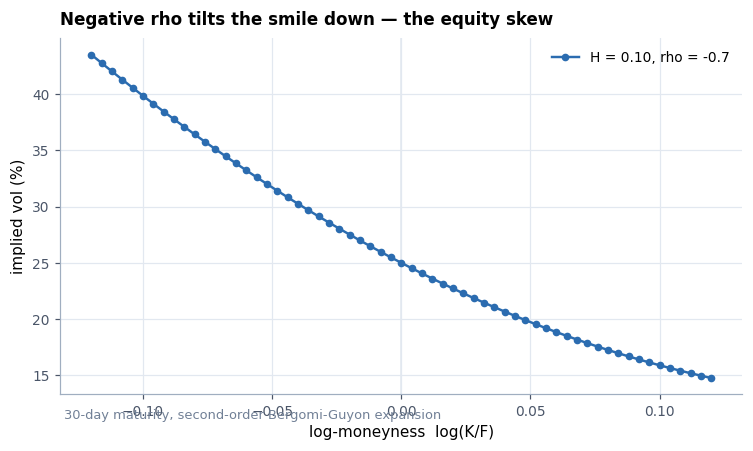

In [12]:
import numpy as np
from rvlab.models.rough import RoughVolParams, bergomi_guyon_smile
from rvlab.plotting import smile_plot

params = RoughVolParams(H=0.10, eta=1.5, rho=-0.7, xi0=0.0625)
k = np.linspace(-0.12, 0.12, 61)

smile_plot(k, bergomi_guyon_smile(100 * np.exp(k), 100.0, 30 / 365, params),
           label="H = 0.10, rho = -0.7",
           title="Negative rho tilts the smile down — the equity skew",
           note="30-day maturity, second-order Bergomi-Guyon expansion");

The same model at several maturities. This is the prediction that matters: the smile is not merely tilted, it gets **steeper as expiry approaches**.

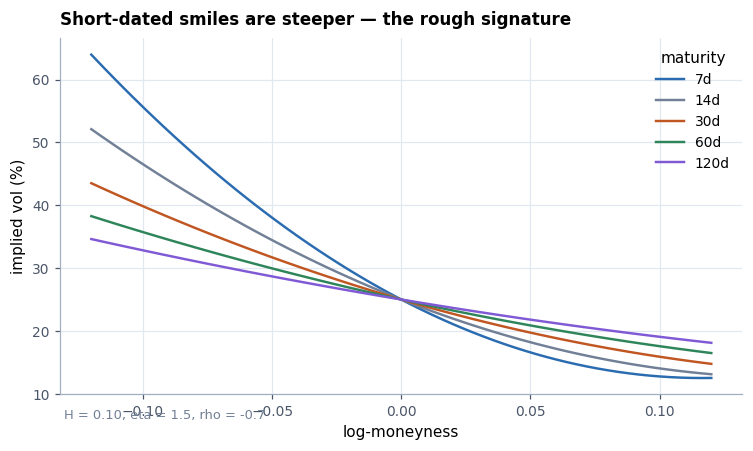

In [13]:
import matplotlib.pyplot as plt
from rvlab.plotting import PALETTE, finish

fig, ax = plt.subplots()
for i, dte in enumerate(MATURITIES):
    ax.plot(k, bergomi_guyon_smile(100 * np.exp(k), 100.0, dte / 365, params) * 100,
            color=PALETTE[i % len(PALETTE)], label=f"{dte}d")
ax.legend(title="maturity")
finish(ax, "Short-dated smiles are steeper — the rough signature",
       "log-moneyness", "implied vol (%)", "H = 0.10, eta = 1.5, rho = -0.7");

## R2.6 · Read the two scaling laws off the model
<a id="r2-6"></a>

**Topic** Model implementation

**Use when** you want the quantitative prediction, not the picture. `psi(T)` is the skew coefficient and scales as `T^(H-1/2)`; the curvature `chi(T)` follows from it.

**Inputs** a `RoughVolParams`.

**Needs** nothing beyond the setup and data cells

**Gotchas** the exponent is the *entire* testable content. `eta` and `rho` set the level of the skew and can absorb a lot of misfit; only the maturity exponent pins down H, which is why [R2.9](#r2-9) regresses against `log(T)` rather than fitting a level.

**See also** [R2.5](#r2-5) (the smile) · [R2.9](what_roughness_claims.ipynb#r2-9) (fitting the exponent)

In [14]:
import numpy as np, pandas as pd
from rvlab.models.rough import RoughVolParams, chi, psi, skew_exponent, curvature_exponent

params = RoughVolParams(H=0.10)
print(f"skew exponent      H - 1/2  = {skew_exponent(params.H):+.2f}")
print(f"curvature exponent 2H - 1   = {curvature_exponent(params.H):+.2f}")

T = np.array(MATURITIES) / 365.0
pd.DataFrame({"dte": MATURITIES, "T": T.round(4),
              "psi(T)": psi(T, params).round(4), "chi(T)": chi(T, params).round(3)})

skew exponent      H - 1/2  = -0.40
curvature exponent 2H - 1   = -0.80


,dte,T,psi(T),chi(T)
0,7,0.0192,-2.1449,18.403
1,14,0.0384,-1.6256,10.570
2,30,0.0822,-1.1984,5.745
3,60,0.1644,-0.9082,3.299
4,120,0.3288,-0.6883,1.895


Verifying that `psi` really is a power law: regressing `log|psi|` on `log T` must return the exponent we put in. If this did not hold, the empirical test in [R2.9](#r2-9) would mean nothing.

In [15]:
slope, _ = np.polyfit(np.log(T), np.log(np.abs(psi(T, params))), 1)
print(f"recovered exponent {slope:+.4f}  (expected {skew_exponent(params.H):+.4f})")
print(f"implied H = {slope + 0.5:.4f}")

recovered exponent -0.4000  (expected -0.4000)
implied H = 0.1000


## R2.7 · Simulate the full model, not just its expansion
<a id="r2-7"></a>

**Topic** Simulation

**Use when** the closed-form expansion is not enough — you need paths, for a hedging experiment or a payoff that has no formula. `roughvol` provides three rough Bergomi schemes.

**Inputs** `roughvol` (falls back gracefully if absent).

**Needs** nothing beyond the setup and data cells

**Gotchas** the hybrid BLP scheme is `O(n log n)` against the exact scheme's `O(n^2)` and is accurate enough for hedging work. Use `exact-gaussian` when you are validating, `blp-hybrid` when you are producing.

**See also** [R2.2](#r2-2) (vectorising) · [R4.16](when_a_result_is_real.ipynb#r4-16) (hedging on these paths)

In [16]:
from rvlab import compat

if compat.ensure_roughvol():
    from rvlab.data.synthetic import rbergomi_panel
    paths = rbergomi_panel(n_paths=N_PATHS, maturity=0.25, n_steps=100,
                           hurst=0.10, seed=SEED)
    print(paths.attrs["generator"], "|", paths.shape)
else:
    print("roughvol unavailable — using the rvlab fBM simulator instead")
    paths = None

roughvol.RoughBergomiModel[blp-hybrid] | (40400, 5)


The spot paths this produces are what [R4.16](when_a_result_is_real.ipynb#r4-16) hedges. Plotting the fan shows the fat-tailed spot distribution that rough volatility generates.

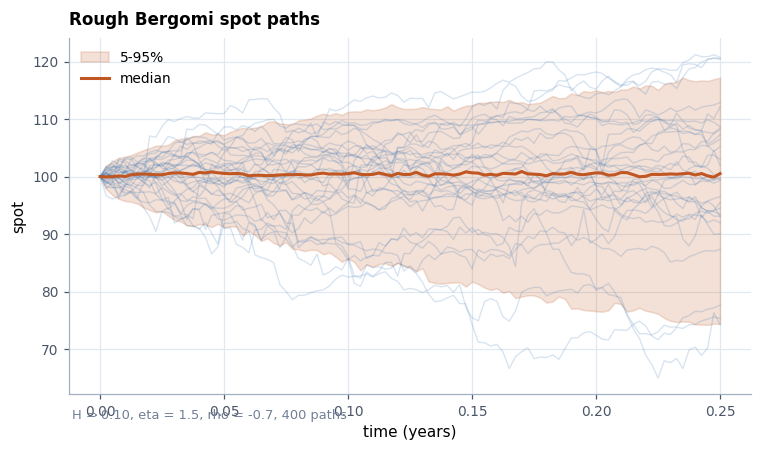

In [17]:
from rvlab.plotting import path_fan

if paths is not None:
    S = paths.pivot(index="path", columns="step", values="spot").to_numpy()
    tg = paths.groupby("step")["t"].first().to_numpy()
    path_fan(tg, S, title="Rough Bergomi spot paths", ylabel="spot",
             note=f"H = 0.10, eta = 1.5, rho = -0.7, {S.shape[0]} paths");
else:
    print("skipped: needs roughvol")

## Estimating the parameter, and testing whether it holds

The same quantity, now measured from the market — with the estimator's own bias measured first, because a downward-biased estimator is exactly how a rough result appears.

Its data cell binds `df`.

In [18]:
from rvlab.data import describe_provenance, load_smile_panel

df = load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE)
print(describe_provenance(df))
print(f"median expiries per timestamp: "
      f"{df.groupby('ts', observed=True).size().median():.0f}")

smile_90d: 380,857 rows from /Users/xiaohao/Effective_Engine/MVP/demo/python/research/cache/gate0b_days90_farF.pkl | 2025-08-07 13:35:00+00:00 -> 2025-12-12 19:55:00+00:00
median expiries per timestamp: 12


## R2.8 · Estimate H from a volatility time series
<a id="r2-8"></a>

**Topic** Regression

**Use when** you have a volatility path (realized or implied) and want its roughness. Fit `log E|X(t+lag) - X(t)|` against `log(lag)`; the slope is H.

**Inputs** a positive volatility series.

**Needs** nothing beyond the setup and data cells

**Gotchas** estimate on a constant-maturity series. Taking the first expiry at each timestamp mixes tenor drift and contract rolls into the increments. The lag range is another choice: always plot the structure function rather than trusting one number.

**See also** [R2.4](what_roughness_claims.ipynb#r2-4) (validated on known ground truth) · [R2.12](#r2-12) (the bias)

In [19]:
import numpy as np
from rvlab.features import hurst_structure_function

def at_constant_tenor(group):
    days = group["T"].to_numpy() * 365.0
    order = np.argsort(days)
    if days.min() > CONSTANT_TENOR_DAYS or days.max() < CONSTANT_TENOR_DAYS:
        return np.nan
    return np.interp(CONSTANT_TENOR_DAYS, days[order],
                     group["atm_iv"].to_numpy()[order])

atm = (df.groupby("ts", observed=True)[["T", "atm_iv"]]
       .apply(at_constant_tenor).dropna().sort_index())
est = hurst_structure_function(atm, min_lag=1, max_lag=64)
print(f"{len(atm):,} constant-{CONSTANT_TENOR_DAYS}d observations · {est}")

32,557 constant-30d observations · H = 0.5437  (R2 = 1.000, 64 lags, 32,557 obs)


Now look at the fit rather than the number. A power law is a *straight line* in log-log space; curvature means the single-exponent description is failing somewhere in the lag range.

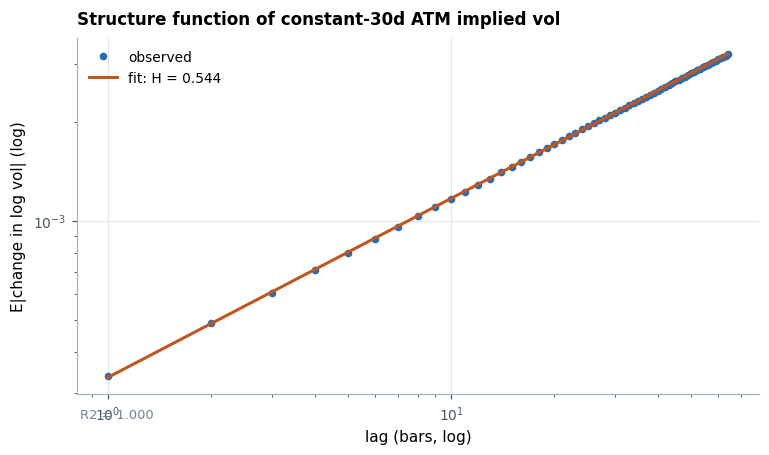

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from rvlab.plotting import C_MODEL, C_OBSERVED, finish

fig, ax = plt.subplots()
ax.loglog(est.lags, est.structure_function, "o", ms=4, color=C_OBSERVED, label="observed")
ax.loglog(est.lags, np.exp(est.intercept) * est.lags ** est.hurst,
          color=C_MODEL, lw=2, label=f"fit: H = {est.hurst:.3f}")
ax.legend()
finish(ax, f"Structure function of constant-{CONSTANT_TENOR_DAYS}d ATM implied vol", "lag (bars, log)",
       "E|change in log vol| (log)", f"R2 = {est.r_squared:.3f}");

## R2.9 · Fit a power law across a cross-section
<a id="r2-9"></a>

**Topic** Regression

**Use when** you have several maturities at one instant and a model predicting a power law in T. Regress in logs: `log|y| = a + b log(T)`, where `b` is the exponent.

**Inputs** one timestamp's slice, with `T` and `rr25`.

**Needs** nothing beyond the setup and data cells

**Gotchas** log-log OLS fits the *median* of a log-normal, not the mean, and it weights small values as heavily as large ones. That is usually what you want for an exponent, and it is not the same as fitting the power law by nonlinear least squares on the raw scale.

**See also** [R2.10](#r2-10) (across all instants) · [R1.23](the_volatility_surface.ipynb#r1-23) (the picture)

In [21]:
from rvlab.features import skew_term_structure_fit, widest_cross_section

slice_ = widest_cross_section(df)
fit = skew_term_structure_fit(slice_, min_points=MIN_EXPIRIES)
fit

{'slope': 0.22663910652098462,
 'intercept': -2.4003448949612745,
 'r_squared': 0.8744382203847206,
 'implied_hurst': 0.7266391065209846,
 'n_points': 13}

The fitted line, drawn over the data it came from. The comparison that matters is against the dashed line — the slope the rough prior H = 0.10 predicts.

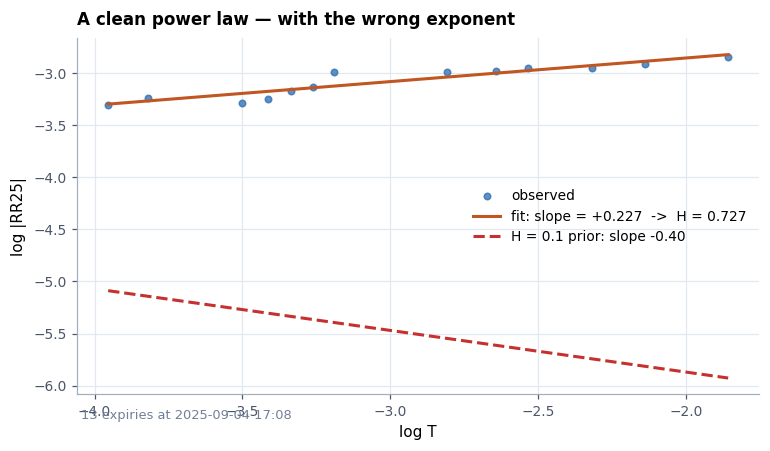

In [22]:
from rvlab.models.rough import skew_exponent
from rvlab.plotting import scaling_fit_plot

fig, ax = scaling_fit_plot(
    slice_["T"], slice_["rr25"], fit["slope"], fit["intercept"],
    implied_hurst=fit["implied_hurst"], r_squared=fit["r_squared"],
    title="A clean power law — with the wrong exponent",
    note=f"{fit['n_points']} expiries at {slice_['ts'].iloc[0]:%Y-%m-%d %H:%M}")
import numpy as np
xs = np.log(slice_["T"].to_numpy())
ax.plot(xs, fit["intercept"] + skew_exponent(H_PRIOR) * (xs - xs.mean()) + np.log(np.abs(slice_["rr25"])).mean(),
        ls="--", color="#c53030", lw=2, label=f"H = {H_PRIOR} prior: slope {skew_exponent(H_PRIOR):+.2f}")
ax.legend();

## R2.10 · Run the same regression at every instant
<a id="r2-10"></a>

**Topic** Regression

**Use when** one fit is an anecdote. Running the cross-sectional regression at every timestamp gives a *distribution* of slopes, which is what tells you whether the exponent is a stable structural constant or a number that wanders.

**Inputs** `df`, and `MAX_TIMESTAMPS` to bound the runtime.

**Needs** nothing beyond the setup and data cells

**Gotchas** subsampling timestamps is fine for the distribution and wrong for anything about autocorrelation. It is a speed compromise; say so where the number is reported.

**See also** [R2.11](#r2-11) (is it stable?) · [R4.8](when_a_result_is_real.ipynb#r4-8) (sweeping)

In [23]:
from rvlab.features import skew_scaling_panel, summarise_skew_scaling

fits = skew_scaling_panel(df, skew_col="rr25", min_points=MIN_EXPIRIES,
                          max_timestamps=MAX_TIMESTAMPS)
summarise_skew_scaling(fits).to_frame("value")

,value
n_timestamps,4070.0000
median_slope,0.2073
mean_r_squared,0.8444
median_r_squared,0.8963
slope_cv,0.4288
median_implied_hurst,0.7073


This is the headline result, and it is a **negative** one.\n\nThe cross-sectional R² is high — around 0.85 — so a power law genuinely describes the term structure. But the fitted slope is **positive**, near +0.21, where the rough prior H = 0.10 predicts **−0.40**. Those differ in sign, not merely in magnitude.\n\nA positive slope means |RR25| *grows* with maturity — the skew is flatter at the short end, not steeper. That is the opposite of the rough signature.

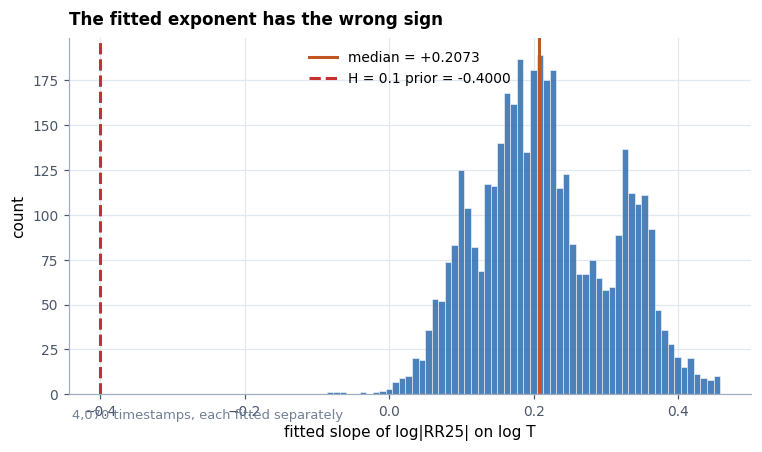

In [24]:
from rvlab.models.rough import skew_exponent
from rvlab.plotting import distribution_plot

distribution_plot(fits["slope"], reference=skew_exponent(H_PRIOR),
                  reference_label=f"H = {H_PRIOR} prior",
                  title="The fitted exponent has the wrong sign",
                  xlabel="fitted slope of log|RR25| on log T",
                  note=f"{len(fits):,} timestamps, each fitted separately");

## R2.11 · Ask whether a well-fitting parameter is actually stable
<a id="r2-11"></a>

**Topic** Diagnostics

**Use when** a model fits well at every point in time. High R² says the *shape* is right; it says nothing about whether the parameter is constant. The coefficient of variation of the fitted slope answers that.

**Inputs** `fits` from [R2.10](#r2-10).

**Needs** R2.10 — run those first. This recipe builds on what they define.

**Gotchas** this is the trap that makes power laws so seductive. Almost any monotone, convex term structure fits a power law over a narrow maturity range with R² > 0.8. A good fit is very weak evidence for the mechanism that motivated it.

**See also** [R2.10](#r2-10) (the distribution) · [R3.21](forecasting_the_smile.ipynb#r3-21) (multiplicity)

In [25]:
import numpy as np

slope = fits["slope"].dropna()
cv = slope.std() / abs(slope.mean())
print(f"mean R2   {fits['r_squared'].mean():.4f}   <- the shape fits well")
print(f"slope CV  {cv:.4f}   <- the exponent is not constant")
print(f"slope IQR {slope.quantile(0.25):+.3f} to {slope.quantile(0.75):+.3f}")

mean R2   0.8444   <- the shape fits well
slope CV  0.4288   <- the exponent is not constant
slope IQR +0.151 to +0.288


A structural constant should not have an interquartile range that wide. Whether the sign is even stable is the sharper question:

In [26]:
print(f"slopes with the sign the rough prior predicts (negative): "
      f"{(slope < 0).mean():.1%}")
print(f"slopes within +/-0.1 of the predicted {skew_exponent(H_PRIOR):+.2f}: "
      f"{(slope.sub(skew_exponent(H_PRIOR)).abs() < 0.1).mean():.1%}")

slopes with the sign the rough prior predicts (negative): 0.2%
slopes within +/-0.1 of the predicted -0.40: 0.0%


## R2.12 · Measure your estimator's bias instead of assuming it away
<a id="r2-12"></a>

**Topic** Estimator bias

**Use when** before believing any estimate. Run the estimator on synthetic data with a *known* answer, then again with observation noise added, and read off how much of the 'finding' the method itself produces.

**Inputs** the synthetic generator, whose H you choose.

**Needs** nothing beyond the setup and data cells

**Gotchas** this is the single most important recipe in the notebook. Noise size only means anything *relative to the signal's own increments* — quoting it in absolute percent hides the effect entirely. Scaled properly, measurement error biases the structure-function estimate of H sharply downward, so noisy data looks rougher.

**See also** [R2.4](what_roughness_claims.ipynb#r2-4) (clean-data validation) · [R1.19](the_volatility_surface.ipynb#r1-19) (stale quotes)

In [27]:
import numpy as np, pandas as pd
from rvlab.data.synthetic import fbm_variance_paths
from rvlab.features import hurst_structure_function

TRUE_H = 0.35                                   # deliberately a *smooth* process
_, vol = fbm_variance_paths(n_paths=1, n_steps=4096, horizon=16.0, hurst=TRUE_H, seed=SEED)
path = vol[0]

# Noise only means something relative to how much the signal itself moves.
step_sd = float(np.std(np.diff(np.log(path))))
print(f"true H = {TRUE_H} | per-step sd of log vol = {step_sd:.4f}")

true H = 0.35 | per-step sd of log vol = 0.2188


Now add observation noise measured **as a fraction of that per-step move**. A ratio of 1.0 means the measurement error on each observation is as large as the genuine change between observations — which is an entirely ordinary situation for an implied vol inverted from a quote with a bid-ask spread.

In [28]:
rng = np.random.default_rng(SEED)
rows = []
for ratio in (0.0, 0.25, 0.5, 1.0, 2.0):
    observed = path * np.exp(rng.normal(0, ratio * step_sd, path.size))
    est = hurst_structure_function(pd.Series(observed), max_lag=64)
    rows.append({"noise / increment": ratio, "estimated_H": round(est.hurst, 4),
                 "r_squared": round(est.r_squared, 4)})
pd.DataFrame(rows)

,noise / increment,estimated_H,r_squared
0,0.00,0.2856,0.9934
1,0.25,0.2803,0.9950
2,0.50,0.2600,0.9941
3,1.00,0.1901,0.9718
4,2.00,0.0836,0.8474


Read the last row. The process really has **H = 0.35** — smooth, closer to a diffusion than to anything rough. Observed with noise twice the size of its own increments, the estimator reports H well under 0.10, and the log-log fit still has R² above 0.8, so nothing about the diagnostic looks wrong.

> ⚠️ **Measurement error:** independent noise adds a constant to every increment's expected size. That inflates the structure function most at short lags, where the true signal is smallest, which flattens the fitted slope downward. A low estimated H is therefore consistent with *either* genuine roughness *or* a smooth process observed badly — and the estimator cannot distinguish them.

Note also the top row: even with no noise at all the estimate sits below the truth, because Riemann-Liouville fBM has non-stationary increments. Both biases point the same way.

In [29]:
table = pd.DataFrame(rows).set_index("noise / increment")["estimated_H"]
print(f"true H = {TRUE_H}")
print(f"  clean                       -> {table[0.0]:.4f}  (bias {table[0.0] - TRUE_H:+.4f})")
print(f"  noise = 1x the increment    -> {table[1.0]:.4f}")
print(f"  noise = 2x the increment    -> {table[2.0]:.4f}  <- reads as 'rough'")

true H = 0.35
  clean                       -> 0.2856  (bias -0.0644)
  noise = 1x the increment    -> 0.1901
  noise = 2x the increment    -> 0.0836  <- reads as 'rough'


## R2.13 · Put a confidence interval on a dependent statistic
<a id="r2-13"></a>

**Topic** Inference

**Use when** you want error bars on a statistic computed from autocorrelated data. Resampling individual observations destroys the dependence and produces intervals that are far too narrow; resampling *blocks* preserves it.

**Inputs** the fitted slopes from [R2.10](#r2-10).

**Needs** R2.10 — run those first. This recipe builds on what they define.

**Gotchas** the block-size rule of thumb `n^(1/3)` is a rule of thumb. Report it, and check that the interval is not wildly sensitive to it before drawing a conclusion from the width.

**See also** [R3.19](forecasting_the_smile.ipynb#r3-19) (bootstrapping skill scores) · [R2.11](#r2-11) (stability)

In [30]:
from rvlab.evaluate import block_bootstrap_ci

block = block_bootstrap_ci(fits["slope"].dropna(), n_boot=N_BOOT, seed=SEED)
iid = block_bootstrap_ci(fits["slope"].dropna(), block_size=1, n_boot=N_BOOT, seed=SEED)

print(f"block bootstrap (b={block['block_size']}): "
      f"[{block['lo']:+.4f}, {block['hi']:+.4f}]  width {block['hi']-block['lo']:.4f}")
print(f"iid bootstrap   (b=1): "
      f"[{iid['lo']:+.4f}, {iid['hi']:+.4f}]  width {iid['hi']-iid['lo']:.4f}")

block bootstrap (b=16): [+0.2068, +0.2285]  width 0.0217
iid bootstrap   (b=1): [+0.2140, +0.2193]  width 0.0053


The i.i.d. interval is narrower — and the extra confidence is an illusion created by pretending consecutive minutes are independent. Either way, the conclusion here is unambiguous:

In [31]:
from rvlab.models.rough import skew_exponent

predicted = skew_exponent(H_PRIOR)
inside = block["lo"] <= predicted <= block["hi"]
print(f"95% CI for the mean slope: [{block['lo']:+.4f}, {block['hi']:+.4f}]")
print(f"rough prior predicts {predicted:+.2f} -> "
      f"{'inside' if inside else 'FAR OUTSIDE'} the interval")

95% CI for the mean slope: [+0.2068, +0.2285]
rough prior predicts -0.40 -> FAR OUTSIDE the interval


## R2.14 · Use statsmodels when you need the inference, not just the fit
<a id="r2-14"></a>

**Topic** Regression

**Use when** numpy's `polyfit` gives you coefficients. When you need standard errors, t-statistics and residual diagnostics, use `statsmodels` — and use HAC standard errors on dependent data, or the t-statistics are fiction.

**Inputs** one cross-section, or a pooled panel.

**Needs** R2.10 — run those first. This recipe builds on what they define.

**Gotchas** the default OLS standard errors assume independent, homoskedastic errors. Neither holds on a smile term structure, where adjacent maturities are nearly the same contract. `cov_type='HAC'` is the minimum correction.

**See also** [R2.9](#r2-9) (the fit) · [R3.18](forecasting_the_smile.ipynb#r3-18) (Diebold-Mariano)

In [32]:
import numpy as np, pandas as pd, statsmodels.api as sm

slice_ = df[df["ts"] == fits.loc[fits["n_points"].idxmax(), "ts"]].sort_values("T")
y = np.log(np.abs(slice_["rr25"].to_numpy()))
X = sm.add_constant(np.log(slice_["T"].to_numpy()))

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})
ci = model.conf_int()
pd.DataFrame({"estimate": model.params, "HAC_std_error": model.bse,
              "t_stat": model.tvalues, "p_value": model.pvalues,
              "ci_low": ci[:, 0], "ci_high": ci[:, 1]},
             index=["constant", "log_T slope"]).round(4)

,estimate,HAC_std_error,t_stat,p_value,ci_low,ci_high
constant,-2.4014,0.0480,-50.0270,0.0,-2.4955,-2.3073
log_T slope,0.2277,0.0173,13.1412,0.0,0.1938,0.2617


The slope with a proper standard error, tested against the value rough volatility predicts. This is the single-instant version of [R2.13](#r2-13).

In [33]:
slope, se = model.params[1], model.bse[1]
predicted = skew_exponent(H_PRIOR)
print(f"slope {slope:+.4f} +/- {se:.4f} (HAC)")
print(f"distance from the H = {H_PRIOR} prediction: "
      f"{(slope - predicted) / se:.1f} standard errors")

slope +0.2277 +/- 0.0173 (HAC)
distance from the H = 0.1 prediction: 36.2 standard errors


## R2.15 · Divide out the maturity scaling and see what is left
<a id="r2-15"></a>

**Topic** Model diagnostics

**Use when** the sharpest form of the test. If H is right, dividing the scaling out leaves a coefficient with no systematic maturity dependence. If a trend in T survives, H is wrong — and the direction of the trend tells you which way.

**Inputs** `df`, and a candidate H.

**Needs** nothing beyond the setup and data cells

**Gotchas** this is more informative than the R² of the fit, because it separates 'a power law describes this' from 'this *particular* power law describes this'.

**See also** [R2.10](#r2-10) (fitted slopes) · [R3.1](forecasting_the_smile.ipynb#r3-1) (as features)

In [34]:
import pandas as pd
from rvlab.features import add_structural_coefficients, add_tenor_bucket

tested = add_tenor_bucket(add_structural_coefficients(df, hurst=H_PRIOR))
by_tenor = (tested.groupby("tenor_bucket", observed=True)["alpha"]
            .agg(["median", "std", "size"]).dropna())
by_tenor

,median,std,size
tenor_bucket,,,
0-10d,-0.0610,0.0101,76133
10-21d,-0.0832,0.0143,142128
21-35d,-0.1260,0.0167,71359
35-60d,-0.1626,0.0194,89063
60-999d,-0.1847,0.0109,2174


If H = 0.10 were correct, the median `alpha` would be flat across these buckets. Sweeping H shows which value, if any, actually flattens it — the answer that the cross-sectional regression already implied.

In [35]:
rows = []
for h in (0.05, 0.10, 0.20, 0.40, 0.71):
    med = (add_tenor_bucket(add_structural_coefficients(df, hurst=h))
           .groupby("tenor_bucket", observed=True)["alpha"].median().dropna())
    rows.append({"H": h, "spread_across_tenors": round(float(med.max() - med.min()), 4),
                 "relative_spread": round(float((med.max() - med.min()) / abs(med.mean())), 4)})
pd.DataFrame(rows).sort_values("relative_spread")

,H,spread_across_tenors,relative_spread
4,0.71,0.0801,0.1323
3,0.40,0.1245,0.4734
2,0.20,0.1318,0.8338
1,0.10,0.1237,1.0015
0,0.05,0.1184,1.0826


## Verdict & what carries forward

A prediction was written down, then measured. The two do not agree, and the sections below say how confidently.

### Volatility models, and what makes one rough

Rough volatility is now a concrete, checkable claim rather than a slogan:

* **Lower H means a rougher volatility path**, and the structure-function estimator recovers
  H accurately on clean simulated data — so a disagreement on market data will be a fact
  about the market, not a broken estimator.
* **The model predicts a specific maturity exponent.** With H = 0.10, skew should scale as
  `T^(-0.40)` and curvature as `T^(-0.80)`. Both are negative: both explode at the short end.
* **The exponent is the whole testable content.** `eta` and `rho` set the level of the skew
  and can absorb a great deal of misfit. Only the exponent pins down H.

That gives the empirical section a falsifiable number. If SPY's skew term structure has a slope near
−0.40, the rough prior survives. If it does not, it does not — and it does not.

Next in this notebook: **Estimating a model parameter, and testing whether it holds**.

### Estimating the parameter, and testing whether it holds

Two measurements, two answers, and the disagreement is the result.

* **Cross-section (risk-neutral).** SPY's skew term structure fits a power law well — mean
  R² ≈ 0.85 — with a median slope near **+0.21**. The H = 0.10 prior predicts **−0.40**.
  These differ in sign. The bootstrap interval does not come close to containing the
  prediction, and only a small minority of instants even have the predicted sign.
* **Time series (physical).** The structure-function estimate lands low, in the range the
  literature reports — but [R2.12](#r2-12) shows a few percent of observation noise moves that
  estimator by more than the effect being claimed. On noisy data it cannot distinguish a
  genuinely rough process from a smooth one observed badly.
* **A good fit is not evidence for the mechanism.** [R2.11](#r2-11) is the general lesson:
  R² above 0.8 with a slope whose coefficient of variation is above 0.4 describes a shape,
  not a constant.

**Verdict on H1: weak / partial support.** A power-law term structure is really there. The
rough-volatility interpretation of its exponent is not confirmed. This matches the status
recorded in `lab/registry/research_gates.json` for `gate1_skew_structure`.

That is enough to doubt the model, and not enough to abandon it — the exponent could be
wrong while the *features* remain useful. [Forecasting the Smile](forecasting_the_smile.ipynb) tests that weaker claim: forget H,
can rough-inspired features forecast the smile at all?

Next: [Forecasting the Smile](forecasting_the_smile.ipynb).